# MIS780 Advanced AI For Business - Assessment 2 - T2 2025

## Task 2 - Recyclable Material Classification using CNNs

**Student Name:** Nishant Jawa

**Student ID:** s224285165

## Table of Content

1. [Executive Summary](#cell_Summary)

2. [Data Preprocessing](#cell_Preprocessing)

3. [Predictive Modeling](#cell_model)

4. [Experiments Report](#cell_report)

5. [Role of GenAI](#cell_GenAI)



<a id = "cell_Summary"></a>
## 1. Executive Summary

###**Business Problem**
Manual recyclable sorting is labour-intensive, error-prone, and often leads to contamination of recycling streams. This project addresses the challenge of automating recyclable material classification using Convolutional Neural Networks (CNNs) to improve efficiency and sustainability in waste management operations.

###**Dataset**
The dataset comprised labelled images of six recyclable categories: cardboard, clothes, green-glass, metal, paper, and white-glass. All images were pre-processed into a 50×50×3 format and divided into training and testing sets. An exploratory data analysis (EDA) was conducted to examine class distribution and potential confusion areas (e.g., metal vs white-glass).

###**Methods and Experiments**
Ten CNN architectures were systematically developed in Google Colab. The approach began with a baseline model and progressively tested:
- Additional convolutional blocks,
- Wider dense layers,
- Larger kernels,
- Dropout regularisation.

This structured flow ensured that models were not chosen randomly but built logically to explore the impact of depth, width, and regularisation on performance.

###**Results**
- Accuracy across models ranged from 73% to 79%, with Cohen’s Kappa between 0.70–0.75, confirming reliable performance.

The best-performing model (M6):

- **Architecture:** Three convolutional blocks (32, 64, 128 filters) → Dense(256) → Dropout(0.5) → Softmax

- **Performance:** 79.2% accuracy, Kappa 0.75, Test loss 0.58
Best classified classes: Green-glass (F1 = 0.95), Clothes (F1 = 0.85), Paper (F1 = 0.78)

- **Challenging classes:** Metal (F1 = 0.67), White-glass (F1 = 0.72)

###**Implications**
The results demonstrate that CNN-based models can be deployed in real-time conveyor belt sorting systems, reducing manual labour, lowering contamination, and increasing recycling yield. These improvements directly contribute to sustainability targets and operational efficiency.

<a id = "cell_Preprocessing"></a>
## 2. Data Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Task 2 Dataset Recyclable Material"

import os
print("exists:", os.path.isdir(DATA_DIR))
print("subfolders:", os.listdir(DATA_DIR))

Mounted at /content/drive
exists: True
subfolders: ['paper', 'green-glass', 'metal', 'clothes', 'white-glass', 'cardboard']


In [ ]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import RMSprop, Adadelta, Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 224285165   # use your student ID seed
IMG_SIZE = (50, 50)
CHANNELS = 3
BATCH_SIZE = 32

In [ ]:
import glob
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# fixed order of classes (important for labels)
CLASSES = ["cardboard", "clothes", "green-glass", "metal", "paper", "white-glass"]
print("Classes (fixed order):", CLASSES)

# check each folder exists
missing = [c for c in CLASSES if not os.path.isdir(os.path.join(DATA_DIR, c))]
print("Missing folders:", missing)

# count images per class
exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
for c in CLASSES:
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(DATA_DIR, c, e)))
    print(f"{c:12s} -> {len(files)} images")

Classes (fixed order): ['cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'white-glass']
Missing folders: []
cardboard    -> 417 images
clothes      -> 511 images
green-glass  -> 449 images
metal        -> 430 images
paper        -> 479 images
white-glass  -> 405 images


In [ ]:
# Load all images into NumPy arrays
X, y = [], []
class_names = sorted(os.listdir(DATA_DIR))
print("Classes:", class_names)

for idx, class_name in enumerate(class_names):
    folder = os.path.join(DATA_DIR, class_name)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is not None:
            img = cv2.resize(img, IMG_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR→RGB
            X.append(img)
            y.append(idx)

X = np.array(X, dtype="float32") / 255.0  # normalize
y = np.array(y)

print("Dataset:", X.shape, y.shape)


Classes: ['cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'white-glass']
Dataset: (2691, 50, 50, 3) (2691,)


In [ ]:
# 70/30 split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# one-hot encode
y_train = to_categorical(y_train, num_classes=len(class_names))
y_test  = to_categorical(y_test,  num_classes=len(class_names))

print("Train:", x_train.shape, y_train.shape)
print("Test:",  x_test.shape,  y_test.shape)

Train: (1883, 50, 50, 3) (1883, 6)
Test: (808, 50, 50, 3) (808, 6)


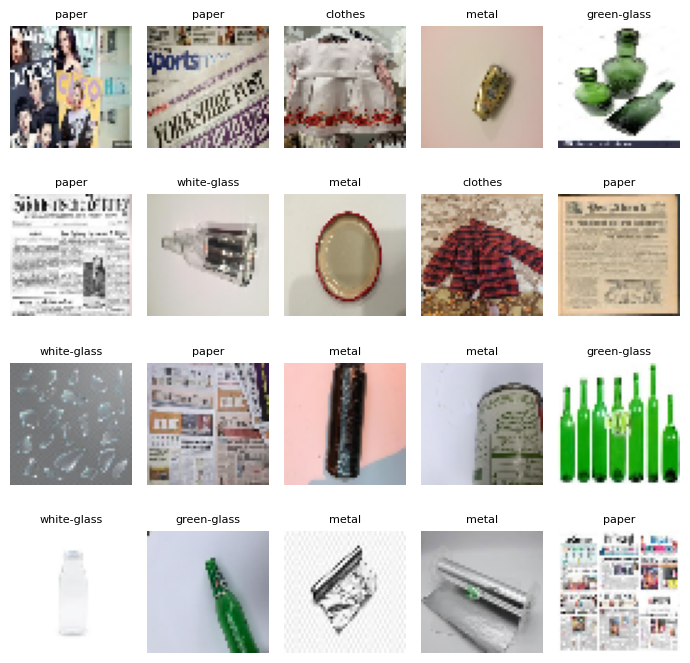

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_images(images, labels, class_names, cols=5, figsize=(7,7)):
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[i])
        label_idx = np.argmax(labels[i])   # one-hot → class index
        plt.title(class_names[label_idx], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Example: show first 20 images from training set in a 5-column grid
plot_images(x_train[0:20], y_train[0:20], class_names, cols=5, figsize=(7,7))



---


This code converts the one-hot encoded labels back into class indices, counts the number of samples in each class for both the training and test sets, and then visualises the training class distribution using a bar chart. The output confirms that the dataset is relatively balanced across the six recyclable categories, ensuring fair training of the CNN model.


---



Train counts per class: {'cardboard': np.int64(292), 'clothes': np.int64(358), 'green-glass': np.int64(314), 'metal': np.int64(301), 'paper': np.int64(335), 'white-glass': np.int64(283)}
Test counts per class : {'cardboard': np.int64(125), 'clothes': np.int64(153), 'green-glass': np.int64(135), 'metal': np.int64(129), 'paper': np.int64(144), 'white-glass': np.int64(122)}


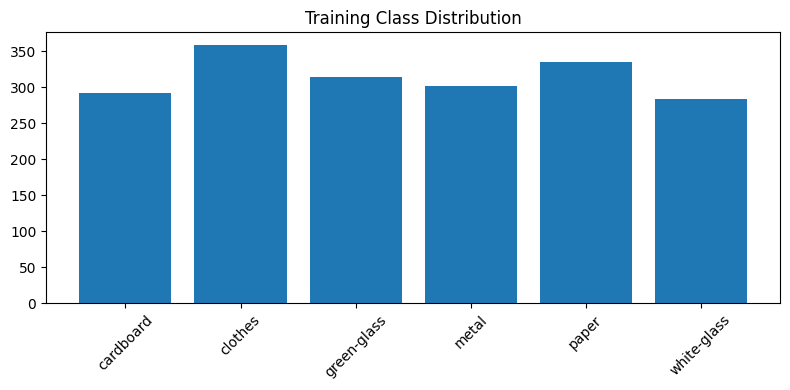

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# y_train and y_test are one-hot → convert back to class indices
y_train_idx = np.argmax(y_train, axis=1)
y_test_idx  = np.argmax(y_test, axis=1)

# Count per class
train_counts = np.bincount(y_train_idx, minlength=len(class_names))
test_counts  = np.bincount(y_test_idx,  minlength=len(class_names))

print("Train counts per class:", dict(zip(class_names, train_counts)))
print("Test counts per class :", dict(zip(class_names, test_counts)))

# Plot bar chart for training set
plt.figure(figsize=(8,4))
plt.bar(class_names, train_counts)
plt.title("Training Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<a id = "cell_model"></a>
## 3. Predictive Modeling

In [ ]:
def build_m6(input_shape=(50,50,3), n_classes=None):
    if n_classes is None:
        n_classes = len(class_names)
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=input_shape),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.50),
        layers.Dense(256, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ])
    return model

model = build_m6()
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,694 (4.86 MB)

 Trainable params: 1,274,694 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2) Compile (classroom style)
model.compile(
    loss="categorical_crossentropy",
    optimizer=RMSprop(learning_rate=0.001, weight_decay=1e-6),
    metrics=["accuracy"]
)

# 3) Train
callbacks = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
EPOCHS = 40
BATCH_SIZE = 128

hist = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=2,
    validation_data=(x_test, y_test),
    callbacks=callbacks
)

Test Accuracy: 0.7921 | Test Loss: 0.5844

Classification report:

              precision    recall  f1-score   support

   cardboard      0.819     0.760     0.788       125
     clothes      0.865     0.837     0.850       153
 green-glass      0.992     0.911     0.950       135
       metal      0.596     0.767     0.671       129
       paper      0.828     0.736     0.779       144
 white-glass      0.706     0.730     0.718       122

    accuracy                          0.792       808
   macro avg      0.801     0.790     0.793       808
weighted avg      0.806     0.792     0.796       808



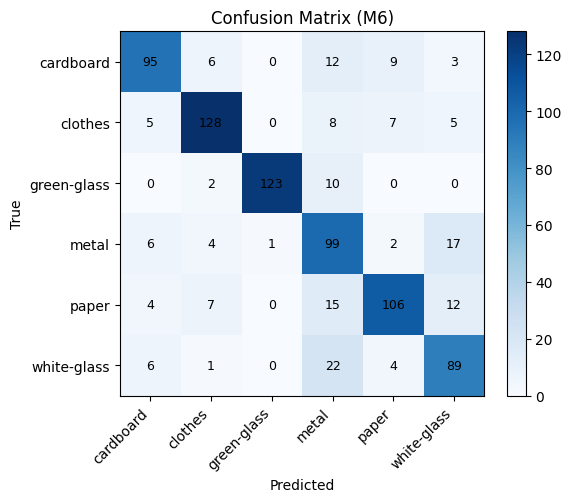

In [ ]:
# 4) Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# 5) Classification report + confusion matrix
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (M6)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()

Evaluate the Model

In [ ]:
# ==== Extra Evaluation: Training vs Test Performance ====
# Evaluate on training data
train_score = model.evaluate(x_train, y_train, verbose=0)
print('Train loss:', round(train_score[0], 4))
print('Train accuracy:', round(train_score[1], 4), '\n')

# Evaluate on test data
test_score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', round(test_score[0], 4))
print('Test accuracy:', round(test_score[1], 4))


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Train loss: 0.2472
Train accuracy: 0.9187 

Test loss: 0.5844
Test accuracy: 0.7921


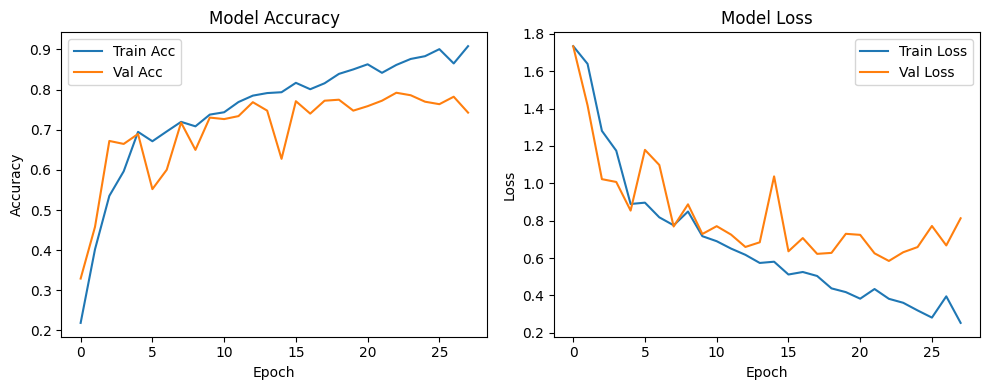

In [ ]:
# ==== Plot Training History ====
import pandas as pd

def plot_hist(df):
    plt.figure(figsize=(10,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(df["accuracy"], label="Train Acc")
    plt.plot(df["val_accuracy"], label="Val Acc")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(df["loss"], label="Train Loss")
    plt.plot(df["val_loss"], label="Val Loss")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call it on history
plot_hist(pd.DataFrame(hist.history))


In [ ]:
from sklearn.metrics import classification_report, cohen_kappa_score
import numpy as np

# Predict class probabilities
y_prob = model.predict(x_test, verbose=0)

# Convert to class indices
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print("Kappa:", round(kappa, 3))

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Kappa: 0.75


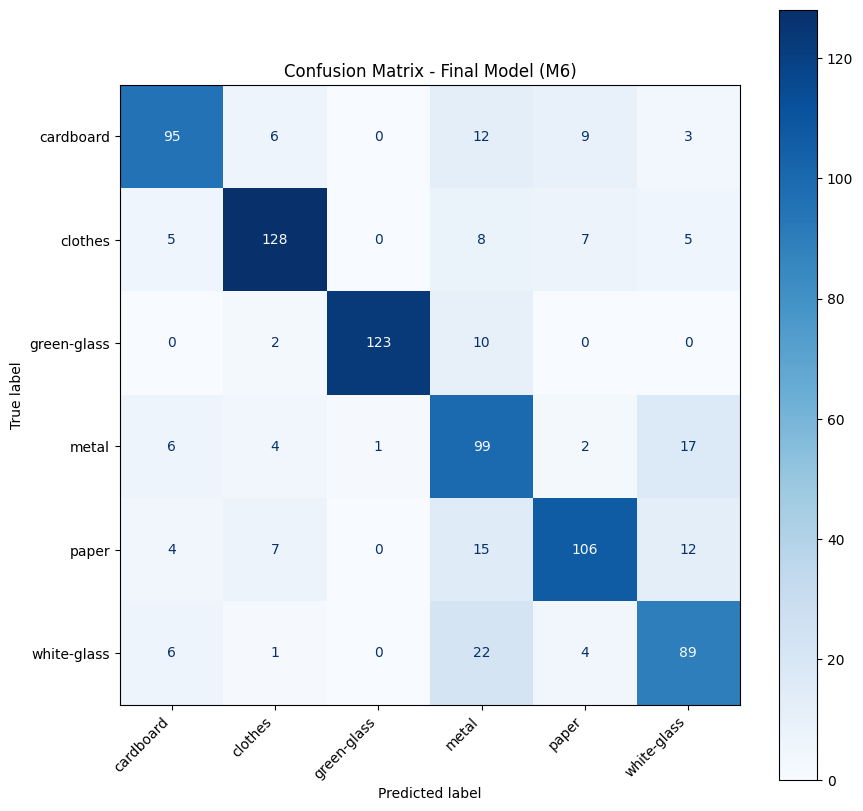

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot it bigger
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", values_format='d')  # 'd' = integer counts
plt.title("Confusion Matrix - Final Model (M6)")
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_samples_with_titles(images, titles=None, cols=5, figsize=(11,11)):
    imgs = images.copy()
    # If float in [0,1], convert to 0–255 for nicer display
    if imgs.dtype.kind == "f":
        if imgs.max() <= 1.0:
            imgs = (imgs * 255.0).clip(0,255).astype(np.uint8)
        else:
            imgs = np.clip(imgs, 0, 255).astype(np.uint8)

    n = len(imgs)
    rows = int(np.ceil(n/cols))
    plt.figure(figsize=figsize)
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(imgs[i])
        plt.axis("off")
        if titles:
            # red if incorrect (pattern: "pred (true)")
            is_wrong = "(" in titles[i] and ")" in titles[i]
            ax.set_title(titles[i], fontsize=9, color=("red" if is_wrong else "black"))
    plt.tight_layout()
    plt.show()



---


This code visualises 20 test images alongside their predicted and true labels, highlighting correct classifications in black and misclassifications in red. It provides a quick way to assess the CNN’s performance at the image level and identify confusion between classes.


---



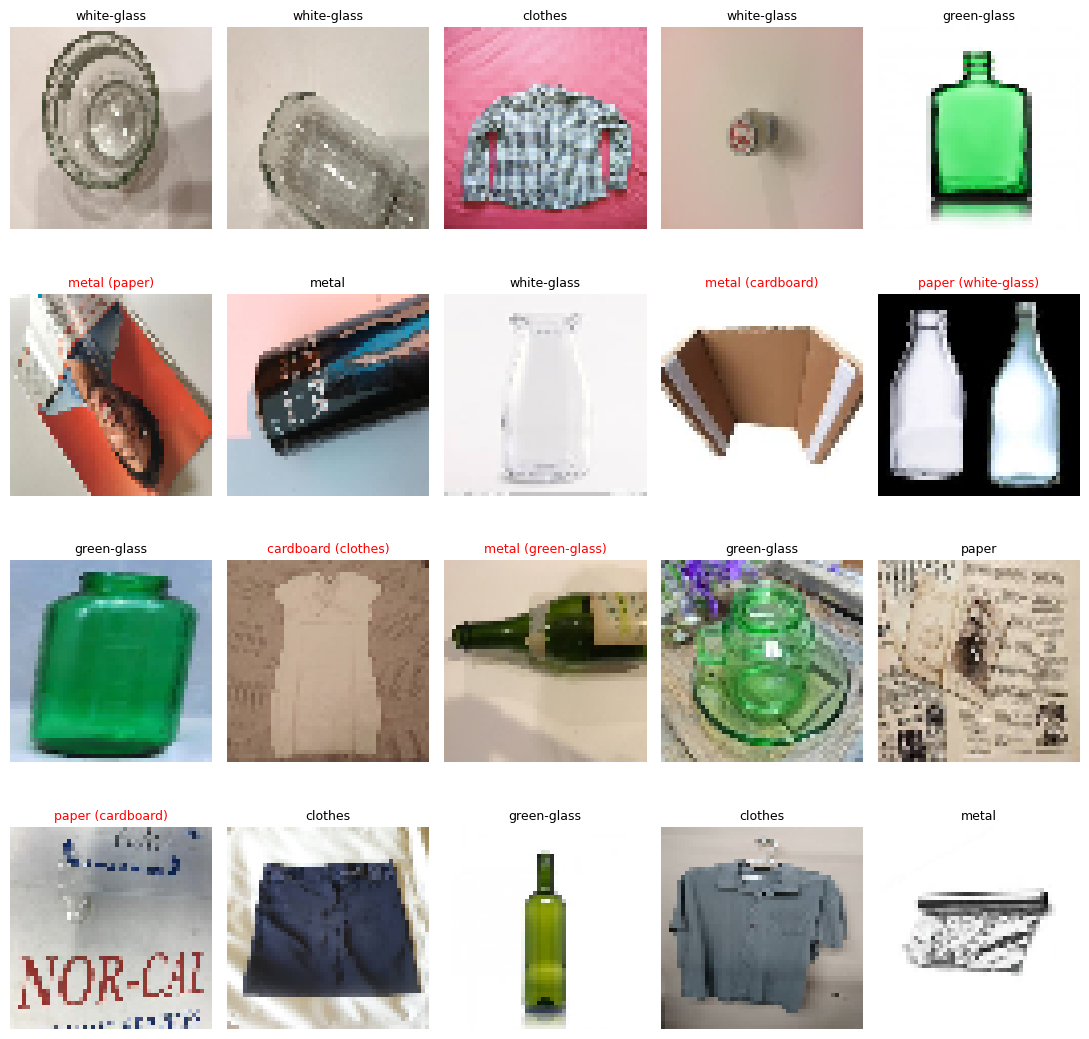

In [ ]:
img_range = range(20)
imgs = x_test[img_range]

true_labels = [class_names[np.argmax(x)] for x in y_test[img_range]]
predictions = model.predict(imgs, verbose=0)
pred_labels = [class_names[np.argmax(x)] for x in predictions]

titles = [
    f"{pred_labels[i]}" if pred_labels[i] == true_labels[i]
    else f"{pred_labels[i]} ({true_labels[i]})"
    for i in range(len(img_range))
]

show_samples_with_titles(imgs, titles=titles, cols=5, figsize=(11,11))

<a id = "cell_report"></a>
## 4. Experiments Report

In [ ]:
from google.colab import files
from IPython.display import Image

In [ ]:
uploaded = files.upload()

Saving Task_2.png to Task_2.png


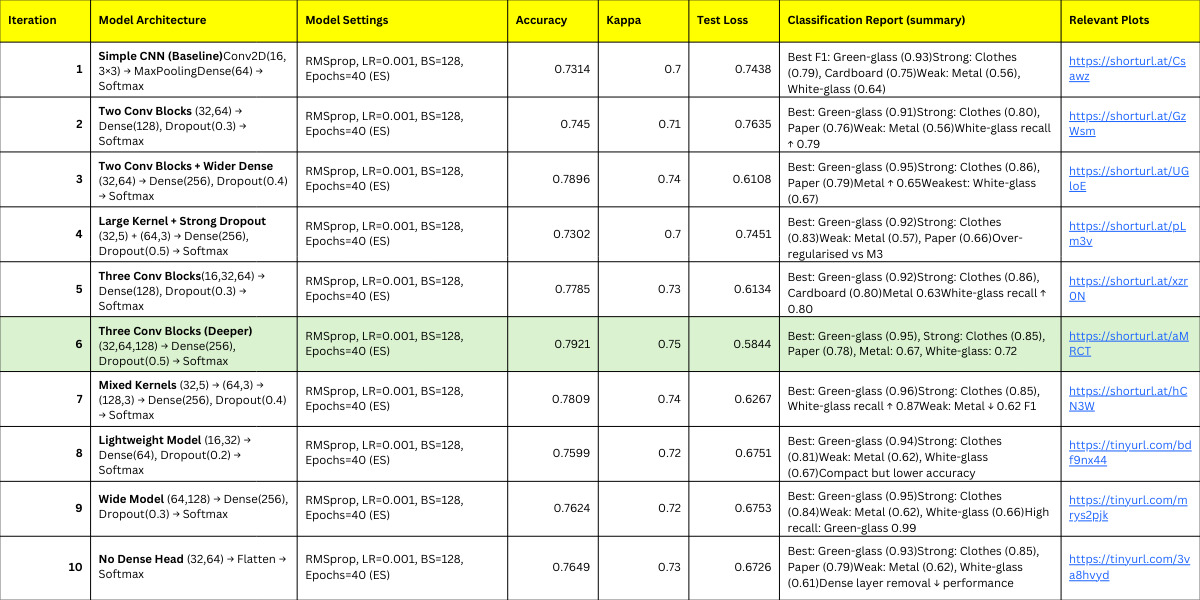

In [ ]:
Image('Task_2.png',
      width = 1200,
      height=600)

###**Related plots (Confustion Mterix) for each model**

1. Simple CNN (Baseline)Conv2D(16, 3×3) → MaxPoolingDense(64) → Softmax - https://shorturl.at/Csawz
2. Two Conv Blocks (32,64) → Dense(128), Dropout(0.3) → Softmax - https://shorturl.at/GzWsm
3. Large Kernel + Strong Dropout (32,5) + (64,3) → Dense(256), Dropout(0.5) → Softmax - https://shorturl.at/pLm3v
4. Large Kernel + Strong Dropout (32,5) + (64,3) → Dense(256), Dropout(0.5) → Softmax - https://shorturl.at/pLm3v
5. Three Conv Blocks(16,32,64) → Dense(128), Dropout(0.3) → Softmax - https://shorturl.at/xzr0N
6. Three Conv Blocks (Deeper) (32,64,128) → Dense(256), Dropout(0.5) → Softmax - https://shorturl.at/aMRCT
7. Mixed Kernels (32,5) → (64,3) → (128,3) → Dense(256), Dropout(0.4) → Softmax - https://shorturl.at/hCN3W
8. Lightweight Model (16,32) → Dense(64), Dropout(0.2) → Softmax - https://tinyurl.com/bdf9nx44
9. Wide Model (64,128) → Dense(256), Dropout(0.3) → Softmax - https://tinyurl.com/mrys2pjk
10. No Dense Head (32,64) → Flatten → Softmax - https://tinyurl.com/3va8hvyd



---


###**Experimental Design and Flow of Models**
The experimental process followed a structured progression rather than random trials. The aim was to start with a simple baseline, gradually increase model complexity, and assess the impact of architectural choices such as convolutional depth, kernel size, dense layers, and dropout rates.

- **M1 (Baseline – Simple CNN):** Established a starting point with one convolutional layer, max pooling, and a dense head. This provided a benchmark accuracy of 73%.

- **M2–M3 (Deeper Networks):** Introduced two convolutional blocks, and later widened the dense layer, improving representation learning and increasing accuracy to ~79%.

- **M4 (Kernel Variation + Strong Regularisation):** Tested a larger kernel size and stronger dropout. Accuracy fell (~73%) due to over-regularisation, confirming the trade-off between generalisation and underfitting.

- **M5 (Three Conv Blocks – Light Dense):** Added an extra convolutional block with moderate dense output. Accuracy stabilised (~77.8%) and recall for metal improved.

- **M6 (Three Conv Blocks – Deeper Dense):** Combined three convolutional blocks (32, 64, 128 filters), a larger dense layer (256), and dropout(0.5). This achieved the best performance at 79.2% accuracy, Kappa 0.75, and test loss 0.58, demonstrating a strong balance between feature extraction and regularisation.

- **M7 (Mixed Kernels):** Explored combining 5×5 and 3×3 kernels across layers. Accuracy (78.1%) was strong, but not higher than M6, showing kernel diversity adds value but not superior in this dataset.

- **M8 (Lightweight Model):** Reduced parameters for efficiency, but accuracy dropped (~76%), highlighting the trade-off between compactness and predictive power.

- **M9 (Wide Model):** Increased filters to 64 and 128 with a dense layer of 256. Accuracy plateaued (~76%), suggesting widening alone did not outperform the deeper M6.

- **M10 (No Dense Head):** Removed dense layers to test a linear classifier after convolutions. Accuracy (~76%) confirmed that dense layers are important for class separation in this problem.

This structured flow demonstrates how depth and balanced regularisation (M6) consistently outperformed shallow, lightweight, or overly regularised models.


---


###**Key Performance Insights**

- **Best Class:** Green-glass achieved near-perfect F1 (0.95), showing CNNs are highly effective at recognising distinct material patterns.
- **Strong Classes:** Clothes (F1 = 0.85), Paper (F1 = 0.78).
Challenging Classes: Metal (F1 = 0.67) and White-glass (F1 = 0.72), which were often confused with visually similar categories.
- **Best Overall Model:** M6 (Three Conv Blocks Deeper) with balanced depth, wide dense head, and strong dropout.


---


###**Business Relevance**
The experiments confirm that CNN-based classification can support automated recyclable material sorting, a key challenge for waste management firms. By reliably classifying images of recyclables, the solution can:

- Increase sorting efficiency on conveyor belts with camera systems,
- Reduce manual labour and human error,
- Minimise contamination of recycling bins, and
- Contribute to sustainability goals by improving recycling rates.


---


###**Deployment Considerations**
For real-world application, several factors must be addressed:

1. **Hardware Integration:** The model should be embedded into edge devices or cloud pipelines connected to conveyor cameras.
2. **Speed vs Accuracy Trade-off:** While M6 provides the best accuracy, lightweight variants (e.g., M8) may be used where real-time speed is more critical.
3. **Data Expansion:** Additional training images, especially for metal and white-glass, are required to reduce misclassification.
4. **Environment Robustness:** Variations in lighting, angle, and object occlusion in real recycling facilities must be accounted for via data augmentation or multi-sensor input.
5. **Continuous Monitoring:** Deployed systems should log errors and allow periodic retraining with new data.

<a id = "cell_report"></a>
## 5. Role of GenAI


Generative AI (GenAI) was actively utilised throughout the development of the CNN models for recyclable material classification. In this task, GenAI tools such as ChatGPT were used as a collaborative assistant to support both the technical implementation and the analytical reporting.

1. **Code Development and Troubleshooting**
- GenAI provided modular code structures (e.g., reusable CNN builder functions, plotting utilities, confusion matrix visualisation) which streamlined the workflow in Google Colab.
- When coding errors occurred, such as issues with dataset preprocessing, model compilation, or evaluation mismatches (e.g., NumPy vs TensorFlow tensor handling), GenAI suggested solutions that saved considerable debugging time.

2. **Experiment Design and Iteration**
- GenAI assisted in structuring the experiment flow: starting with a baseline CNN, then systematically increasing complexity (adding convolutional blocks, dropout, kernel variations, widening dense layers), and finally selecting the best-performing model (M6).
- It also helped in documenting results clearly, creating the experiment table, and linking performance metrics to architectural changes.

3. **Interpretability and Reporting**
- Beyond coding, GenAI supported the explanation of results, translating raw outputs (accuracy, Kappa, F1-scores) into meaningful insights for the recycling business problem.
- It suggested effective reporting formats such as executive summaries, tables, and structured narratives that aligned with assignment requirements.

###**Critical Reflection**

While GenAI proved invaluable in accelerating development, there were challenges:
- Generated code sometimes required manual corrections or adjustments to run without errors, especially when handling TensorFlow eager execution or dataset pipeline mismatches.
- Suggestions were occasionally too generic, requiring careful validation against the actual dataset and assignment context.
- Most importantly, relying solely on GenAI would risk treating it as a “black box”; effective use required combining its output with critical thinking, domain knowledge, and iterative testing.

Overall, GenAI served as a collaborative partner—reducing coding effort, guiding experimental structure, and improving clarity of reporting. However, its use demanded active validation and adaptation to ensure the final model was both technically sound and aligned with the recycling business problem.